## Load and Import

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [138]:
train_set = pd.read_csv("../data/training_set_VU_DM.csv", nrows = 500000)

In [139]:
train_set.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


# Part 2 - Eda

In [140]:
df = train_set.copy()

In [141]:
df.columns

Index(['srch_id', 'date_time', 'site_id', 'visitor_location_country_id',
       'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id',
       'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool',
       'prop_location_score1', 'prop_location_score2',
       'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag',
       'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score',
       'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv',
       'comp6_rate_percent_diff', 'comp7_rate'

In [142]:
print(df.shape)
df.duplicated(subset = ["srch_id", "prop_id"]).sum()  # prop_id is always unique within one search

(500000, 54)


np.int64(0)

### 2.1 Adding Date Day

In [143]:
df.dtypes[:3]

srch_id       int64
date_time    object
site_id       int64
dtype: object

In [144]:
df["date_time"] = pd.to_datetime(df["date_time"])
date_col = df["date_time"].dt.floor("D")
df.insert(2, "date", date_col)
df.head()

,srch_id,date_time,date,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,893,3,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,10404,4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,21315,3,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,27348,2,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,29604,4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [145]:
df.dtypes[:3]

srch_id               int64
date_time    datetime64[ns]
date         datetime64[ns]
dtype: object

### 2.2 Handling Data Types

In [146]:
df.nunique().sort_values(ascending = False)

orig_destination_distance      158367
prop_id                         81716
price_usd                       39916
srch_query_affinity_score       29773
srch_id                         20058
date_time                       20044
gross_bookings_usd              12023
prop_location_score2             7899
srch_destination_id              5808
visitor_hist_adr_usd             1041
prop_log_historical_price         351
srch_booking_window               344
prop_location_score1              336
comp2_rate_percent_diff           314
comp5_rate_percent_diff           303
comp3_rate_percent_diff           271
comp1_rate_percent_diff           261
date                              242
comp7_rate_percent_diff           238
visitor_hist_starrating           227
comp8_rate_percent_diff           220
comp4_rate_percent_diff           218
comp6_rate_percent_diff           178
visitor_location_country_id       145
prop_country_id                   142
position                           40
site_id     

In [147]:
df.dtypes

srch_id                                 int64
date_time                      datetime64[ns]
date                           datetime64[ns]
site_id                                 int64
visitor_location_country_id             int64
visitor_hist_starrating               float64
visitor_hist_adr_usd                  float64
prop_country_id                         int64
prop_id                                 int64
prop_starrating                         int64
prop_review_score                     float64
prop_brand_bool                         int64
prop_location_score1                  float64
prop_location_score2                  float64
prop_log_historical_price             float64
position                                int64
price_usd                             float64
promotion_flag                          int64
srch_destination_id                     int64
srch_length_of_stay                     int64
srch_booking_window                     int64
srch_adults_count                 

In [148]:
cont_cols = ['visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_review_score', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'srch_query_affinity_score', 'orig_destination_distance', 'gross_bookings_usd', 'comp1_rate_percent_diff', 'comp2_rate_percent_diff', 'comp3_rate_percent_diff', 'comp4_rate_percent_diff', 'comp5_rate_percent_diff', 'comp6_rate_percent_diff', 'comp7_rate_percent_diff', 'comp8_rate_percent_diff']

bool_cols = ['prop_brand_bool', 'promotion_flag', 'srch_saturday_night_bool', 'random_bool', 'click_bool', 'booking_bool']

id_cols = ['srch_id', 'site_id', 'visitor_location_country_id', 'prop_country_id', 'prop_id', 'srch_destination_id']

cat_cols = ['prop_starrating', 'comp1_rate', 'comp1_inv', 'comp2_rate', 'comp2_inv', 'comp3_rate', 'comp3_inv', 'comp4_rate', 'comp4_inv', 'comp5_rate', 'comp5_inv', 'comp6_rate', 'comp6_inv', 'comp7_rate', 'comp7_inv', 'comp8_rate', 'comp8_inv']

int_cols = ['position', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count']

time_cols = ['date_time', 'date']

In [149]:
print(df.shape[1])
col_len = len(cont_cols) + len(bool_cols) + len(id_cols) + len(int_cols) + len(time_cols) + len(cat_cols)
print(col_len)

55
55


In [150]:
df[cont_cols] = df[cont_cols].astype('float32')
df[bool_cols] = df[bool_cols].astype('bool')
df[id_cols + cat_cols] = df[id_cols + cat_cols].astype('category')
df[int_cols] = df[int_cols].astype('int8')

In [151]:
df.dtypes

srch_id                              category
date_time                      datetime64[ns]
date                           datetime64[ns]
site_id                              category
visitor_location_country_id          category
visitor_hist_starrating               float32
visitor_hist_adr_usd                  float32
prop_country_id                      category
prop_id                              category
prop_starrating                      category
prop_review_score                     float32
prop_brand_bool                          bool
prop_location_score1                  float32
prop_location_score2                  float32
prop_log_historical_price             float32
position                                 int8
price_usd                             float32
promotion_flag                           bool
srch_destination_id                  category
srch_length_of_stay                      int8
srch_booking_window                      int8
srch_adults_count                 

### 2.3 Missing Values

In [152]:
df.nunique().sort_values(ascending = False)

orig_destination_distance      158367
prop_id                         81716
price_usd                       39916
srch_query_affinity_score       29773
srch_id                         20058
date_time                       20044
gross_bookings_usd              12023
prop_location_score2             7899
srch_destination_id              5808
visitor_hist_adr_usd             1041
prop_log_historical_price         351
prop_location_score1              336
comp2_rate_percent_diff           314
comp5_rate_percent_diff           303
comp3_rate_percent_diff           271
comp1_rate_percent_diff           261
srch_booking_window               256
date                              242
comp7_rate_percent_diff           238
visitor_hist_starrating           227
comp8_rate_percent_diff           220
comp4_rate_percent_diff           218
comp6_rate_percent_diff           178
visitor_location_country_id       145
prop_country_id                   142
position                           40
site_id     

In [153]:
miss_ratio = round(df.isna().sum().sort_values(ascending = False) / df.shape[0], 7)
miss_ratio

comp1_rate_percent_diff        0.981470
comp6_rate_percent_diff        0.979804
comp1_rate                     0.976690
comp1_inv                      0.974786
comp4_rate_percent_diff        0.973318
gross_bookings_usd             0.972190
comp7_rate_percent_diff        0.970540
comp6_rate                     0.949476
visitor_hist_starrating        0.948498
visitor_hist_adr_usd           0.948202
comp6_inv                      0.944988
comp4_rate                     0.937552
srch_query_affinity_score      0.934882
comp7_rate                     0.933944
comp4_inv                      0.930430
comp7_inv                      0.925352
comp3_rate_percent_diff        0.904104
comp2_rate_percent_diff        0.888682
comp8_rate_percent_diff        0.878524
comp5_rate_percent_diff        0.831306
comp3_rate                     0.689864
comp3_inv                      0.666356
comp8_rate                     0.617974
comp8_inv                      0.603586
comp2_rate                     0.591976


In [154]:
# Gross USD Availability
nr_bookings = df[df["booking_bool"] == 1].shape[0]

nr_gross_given_booking = df[
    (df["booking_bool"] == 1) & (df["gross_bookings_usd"].notna())
].shape[0]

ratio = nr_gross_given_booking / nr_bookings

print(f"Gross USD Availability Ratio (given booking): {ratio:.5f}")

Gross USD Availability Ratio (given booking): 1.00000


In [155]:
# Affinity Score: number of unique values
df.groupby("prop_id", observed = True)["srch_query_affinity_score"].nunique().sort_values(ascending = False)

prop_id
53494     10
105123    10
41400     10
113402    10
90380     10
          ..
140815     0
140814     0
140813     0
140812     0
140811     0
Name: srch_query_affinity_score, Length: 81716, dtype: int64

In [156]:
# Overall booking rate
overall_booking_rate = df["booking_bool"].mean()

print("=== Overall Booking Rate ===")
print(f"Overall booking probability: {overall_booking_rate:.5f}\n")


# Competition 5: missing vs not missing
comp5_missing_rate = df[df["comp5_rate"].isna()]["booking_bool"].mean()
comp5_not_missing_rate = df[df["comp5_rate"].notna()]["booking_bool"].mean()

print("=== Competition 5 Availability ===")
print(f"Booking probability when comp5_rate is MISSING: {comp5_missing_rate:.5f}")
print(f"Booking probability when comp5_rate is AVAILABLE: {comp5_not_missing_rate:.5f}\n")


# All competition data missing
comp_rate_cols = [f"comp{i}_rate" for i in range(1, 9)]
all_missing = df[comp_rate_cols].isna().all(axis=1)

all_missing_ratio = all_missing.mean()
all_missing_booking_rate = df[all_missing]["booking_bool"].mean()

print("=== All Competitor Data Missing ===")
print(f"Proportion of rows where ALL competitor rates are missing: {all_missing_ratio:.5f}")
print(f"Booking probability when ALL competitor data is missing: {all_missing_booking_rate:.5f}\n")


# Any competitor cheaper
any_cheaper = (df[comp_rate_cols] == -1).any(axis=1)
booking_by_cheaper = df.groupby(any_cheaper)["booking_bool"].mean()

print("=== Effect of Cheaper Competitors ===")
print(f"Booking probability when NO competitor is cheaper: {booking_by_cheaper[False]:.5f}")
print(f"Booking probability when AT LEAST ONE competitor is cheaper: {booking_by_cheaper[True]:.5f}")

=== Overall Booking Rate ===
Overall booking probability: 0.02781

=== Competition 5 Availability ===
Booking probability when comp5_rate is MISSING: 0.02736
Booking probability when comp5_rate is AVAILABLE: 0.02836

=== All Competitor Data Missing ===
Proportion of rows where ALL competitor rates are missing: 0.34609
Booking probability when ALL competitor data is missing: 0.02584

=== Effect of Cheaper Competitors ===
Booking probability when NO competitor is cheaper: 0.02822
Booking probability when AT LEAST ONE competitor is cheaper: 0.02473


In [157]:
df[["comp1_rate", "comp2_rate", "comp3_rate", "comp4_rate", "comp5_rate", "comp6_rate", "comp7_rate", "comp8_rate"]].isna().corr()

,comp1_rate,comp2_rate,comp3_rate,comp4_rate,comp5_rate,comp6_rate,comp7_rate,comp8_rate
comp1_rate,1.000000,-0.068572,-0.043118,0.055502,0.157013,0.291830,0.297521,-0.039789
comp2_rate,-0.068572,1.000000,0.532337,0.126386,0.313545,-0.176073,-0.206851,0.530873
comp3_rate,-0.043118,0.532337,1.000000,0.132777,0.270681,-0.146100,-0.167035,0.597692
comp4_rate,0.055502,0.126386,0.132777,1.000000,0.198619,-0.041797,-0.054028,-0.081729
comp5_rate,0.157013,0.313545,0.270681,0.198619,1.000000,0.214884,0.240959,0.308136
comp6_rate,0.291830,-0.176073,-0.146100,-0.041797,0.214884,1.000000,0.660954,-0.163780
comp7_rate,0.297521,-0.206851,-0.167035,-0.054028,0.240959,0.660954,1.000000,-0.187674
comp8_rate,-0.039789,0.530873,0.597692,-0.081729,0.308136,-0.163780,-0.187674,1.000000


### 2.4 Feature Distributions

#### Category Features (not IDs)

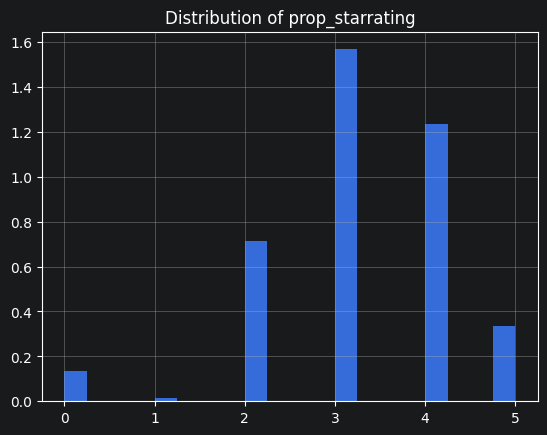

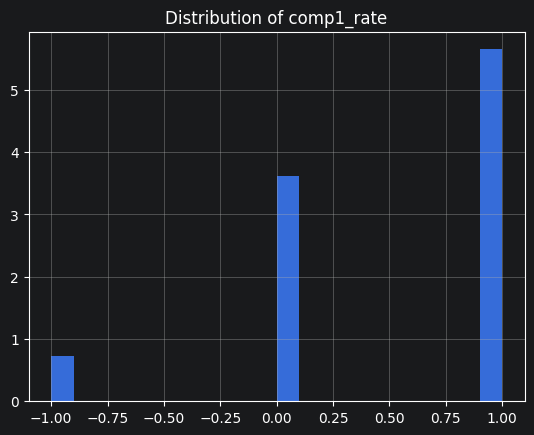

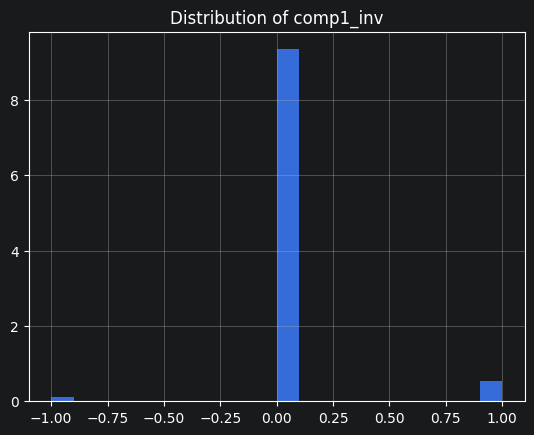

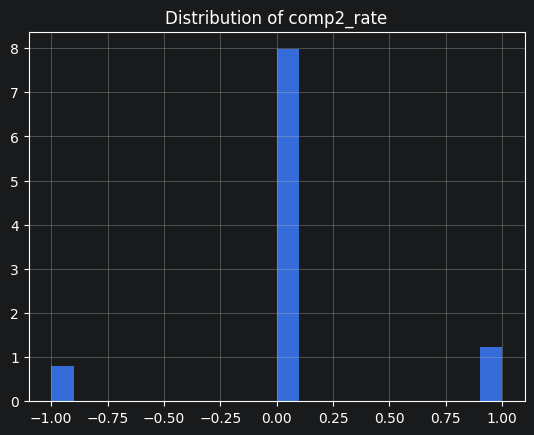

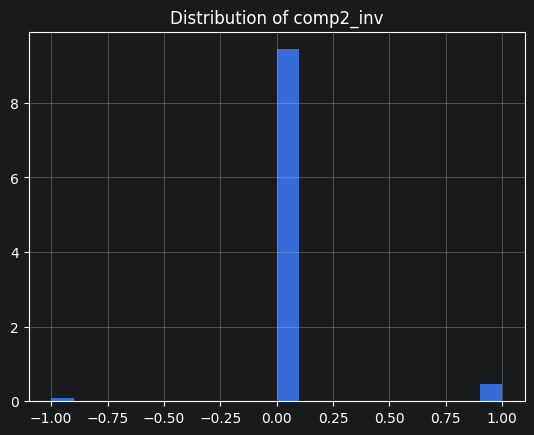

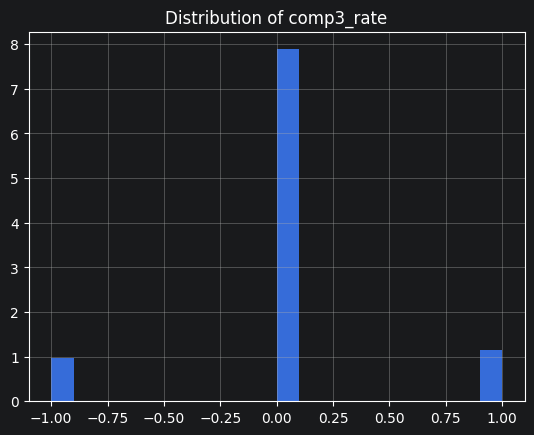

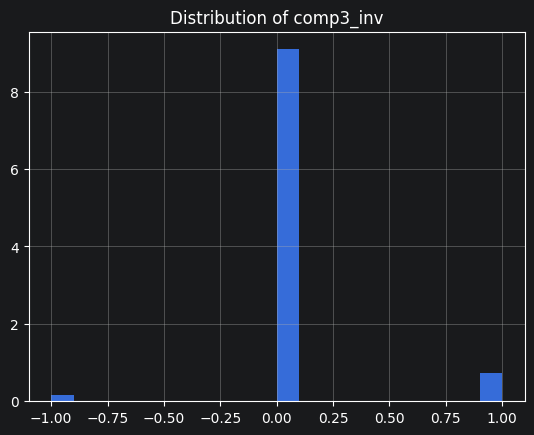

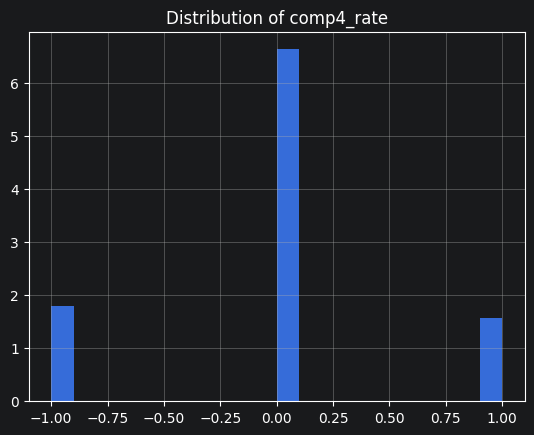

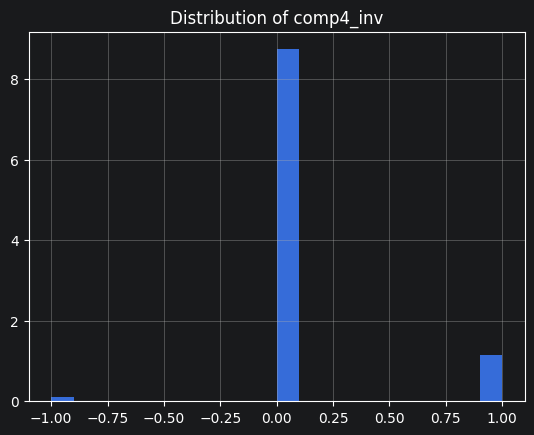

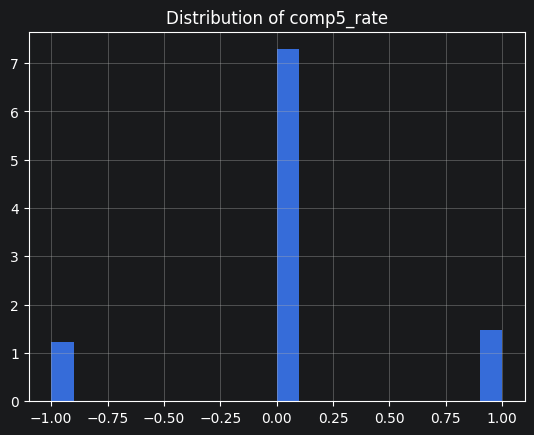

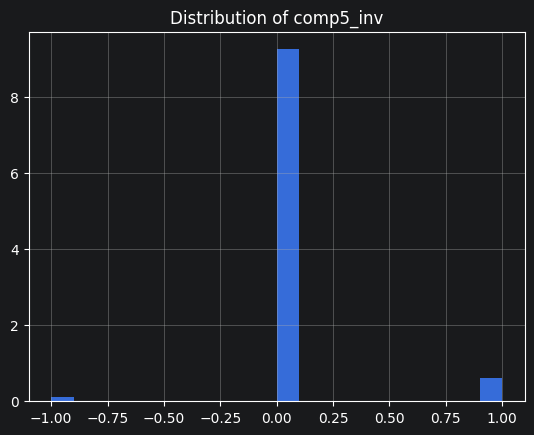

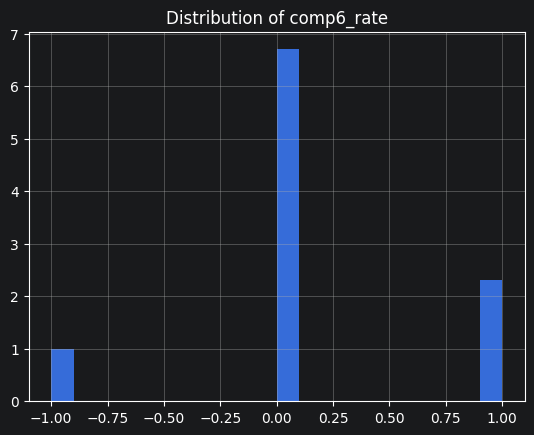

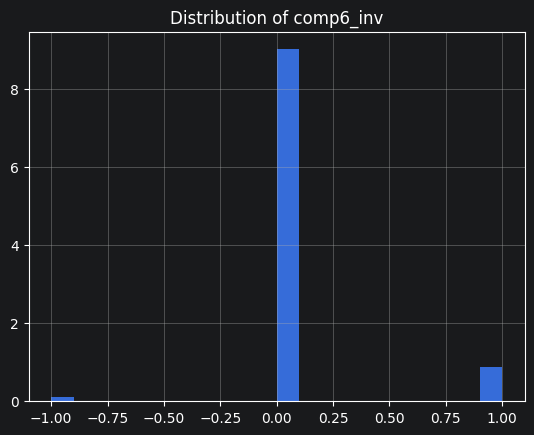

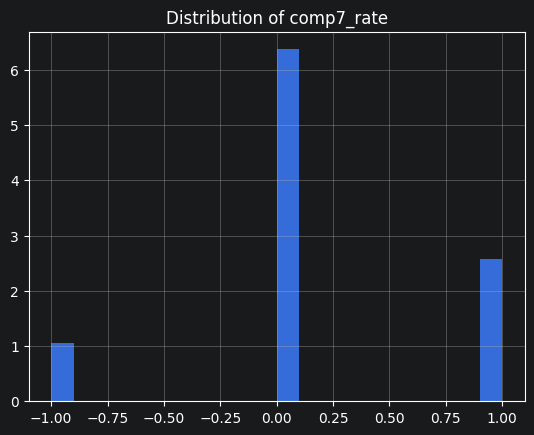

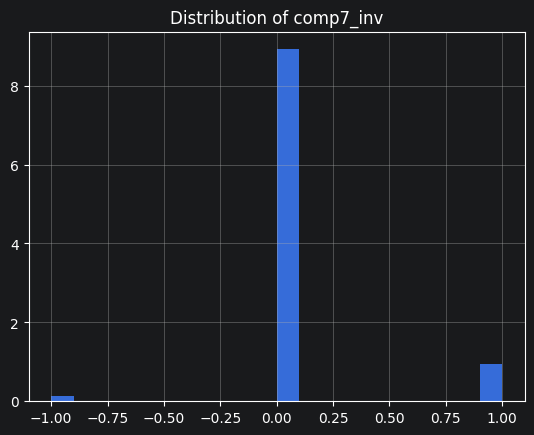

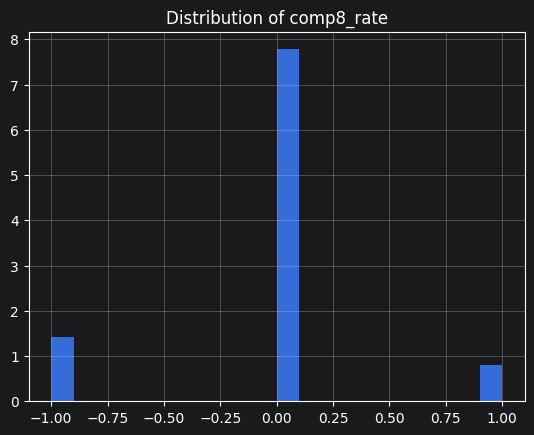

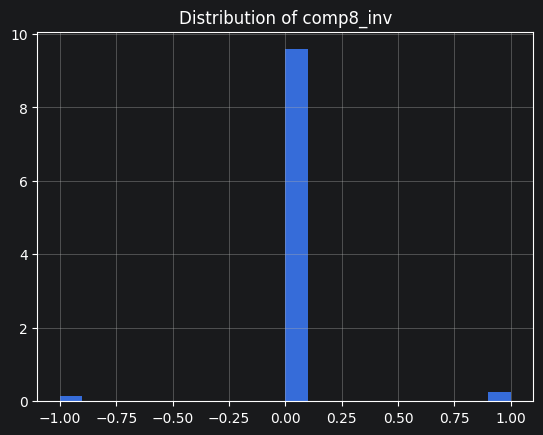

In [158]:
for col in cat_cols:
    plt.figure()
    df[col].hist(bins = 20, density = True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [159]:
df[(df["comp5_inv"] == -1) & (df["booking_bool"] == 1)].shape[0]

85

#### Numeric Features

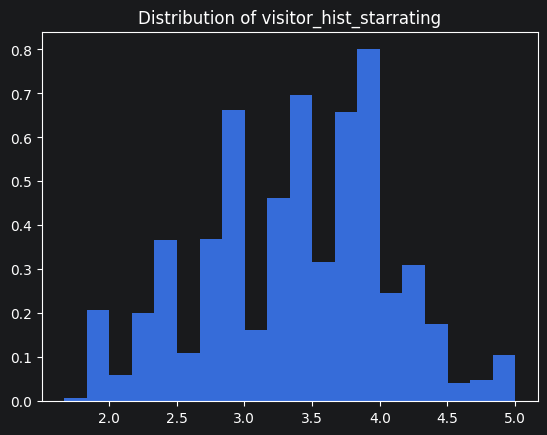

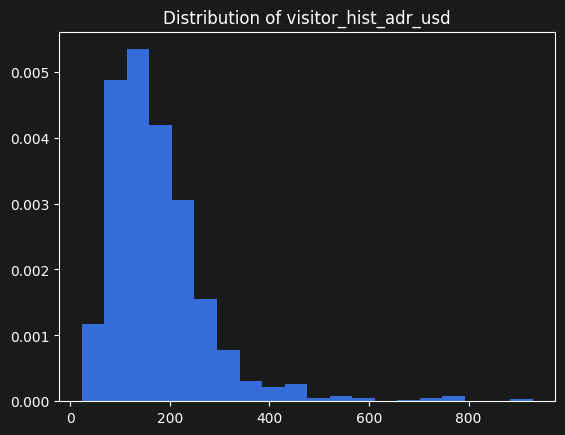

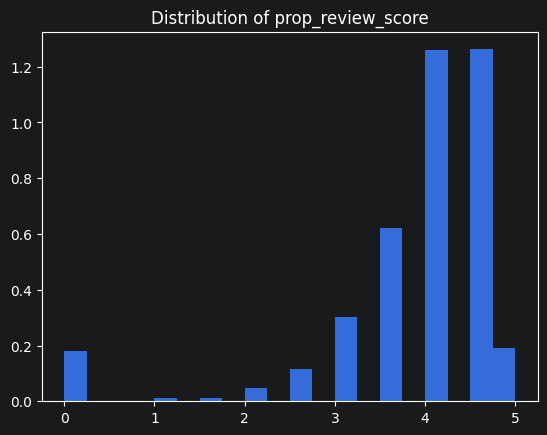

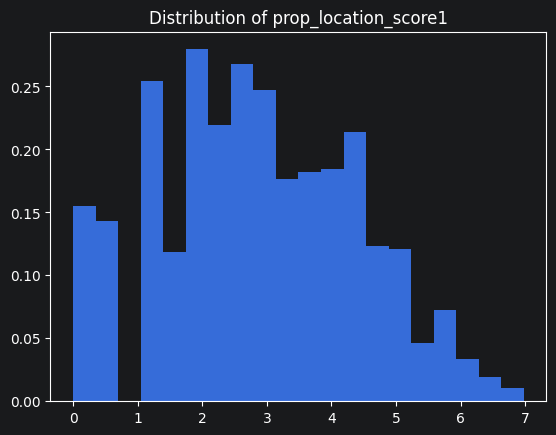

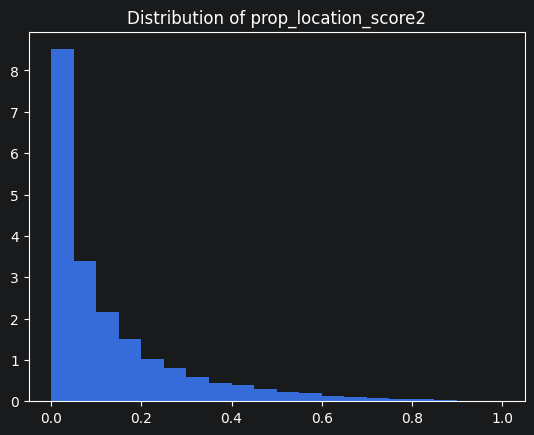

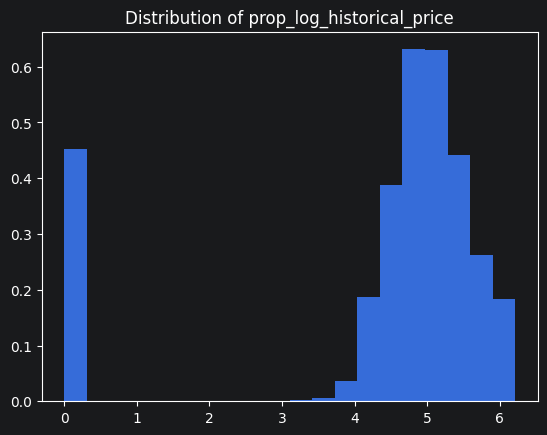

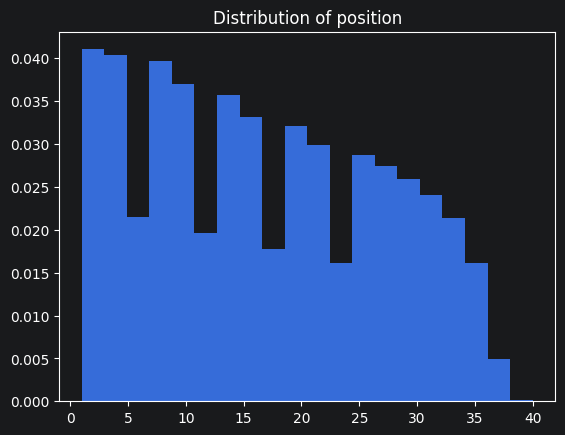

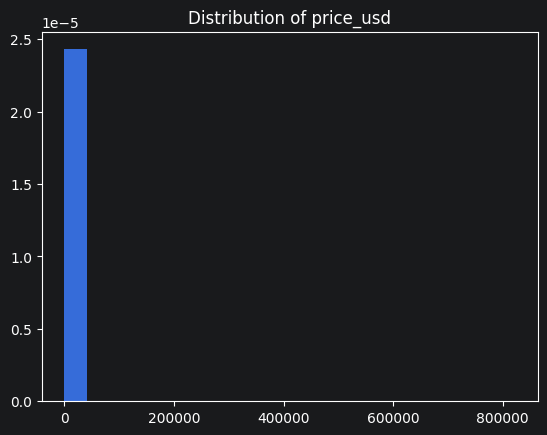

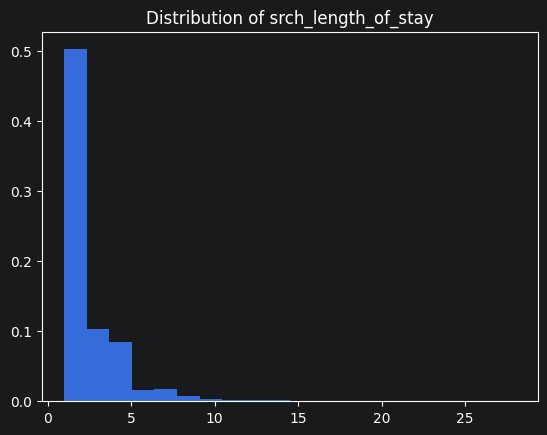

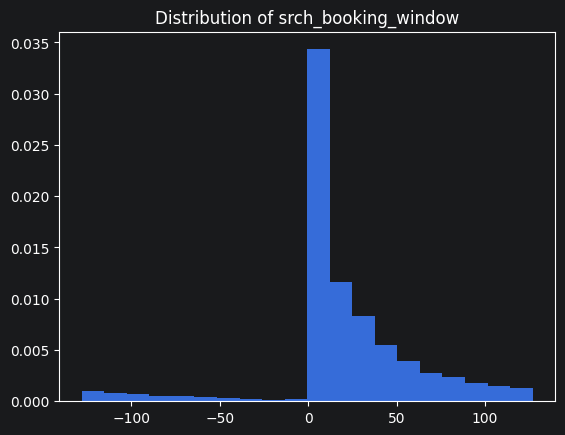

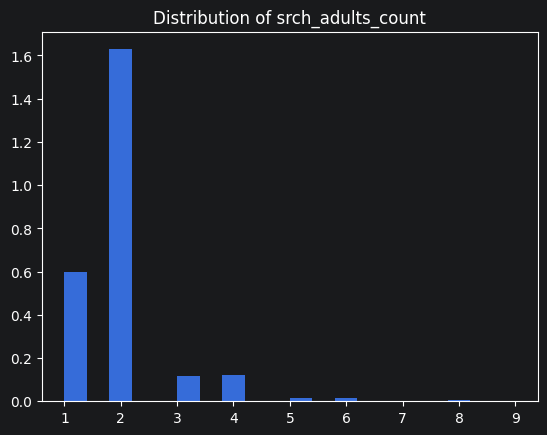

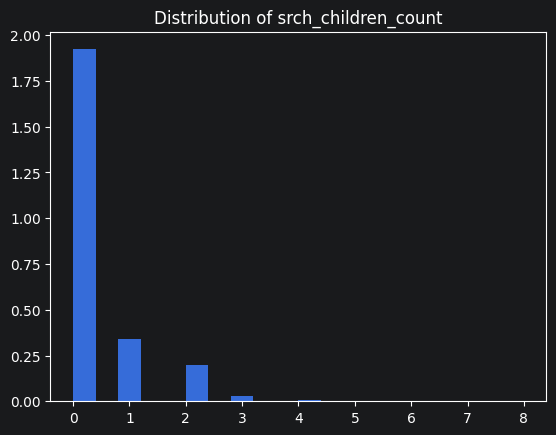

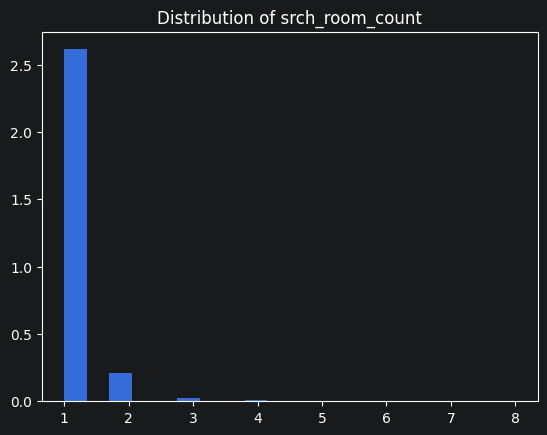

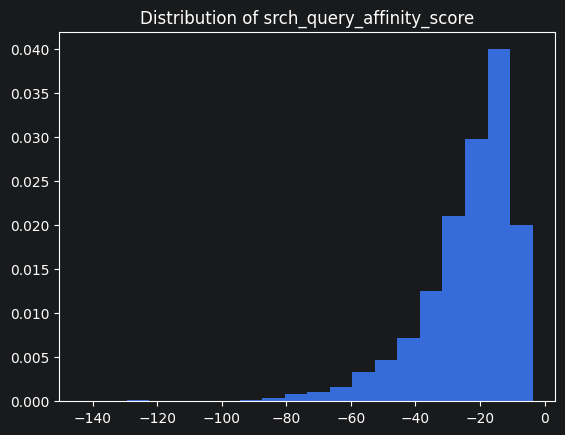

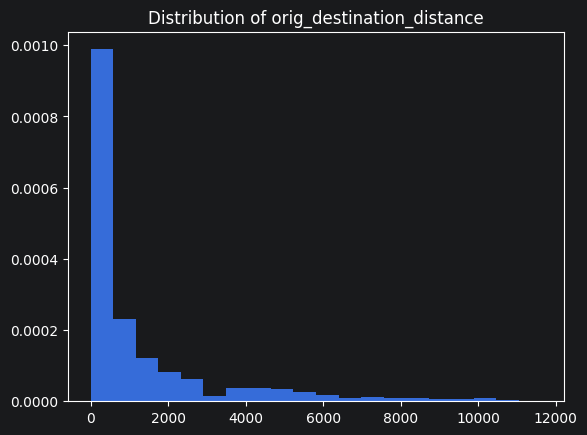

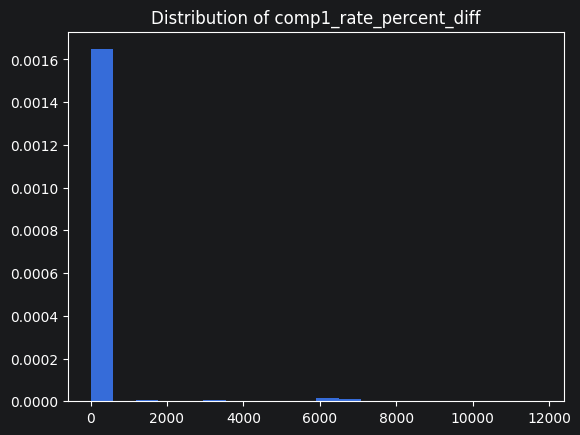

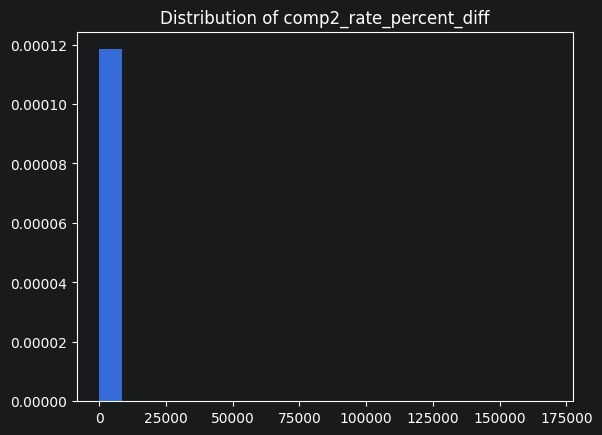

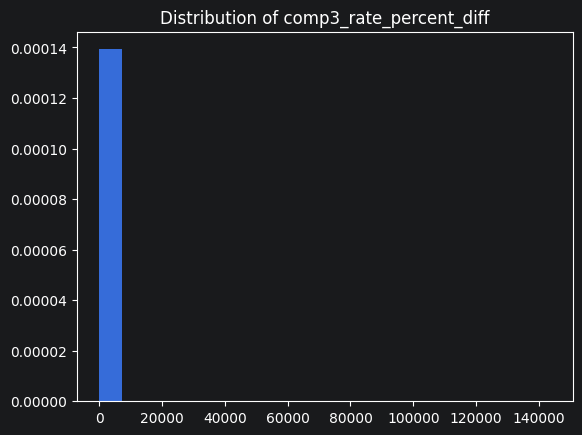

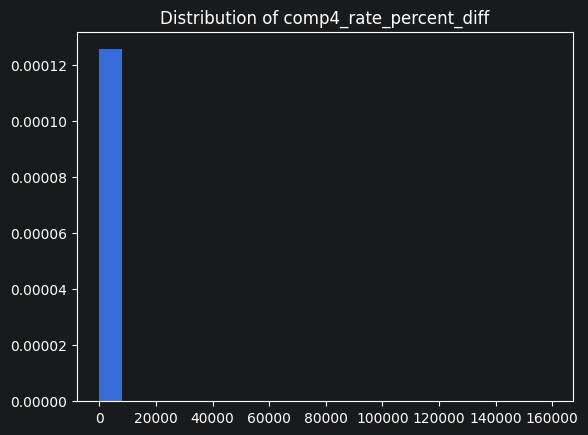

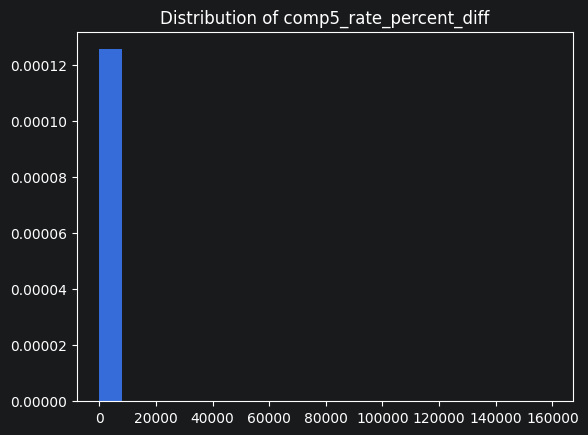

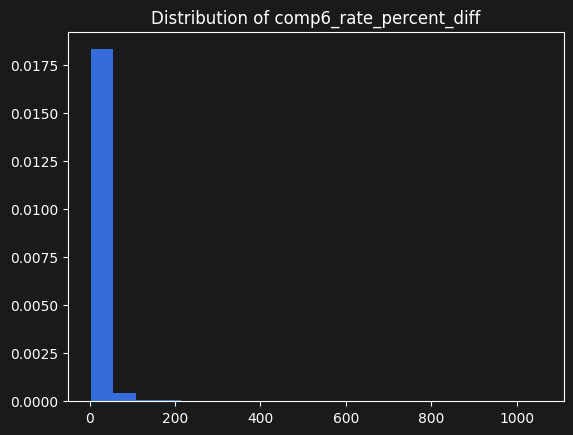

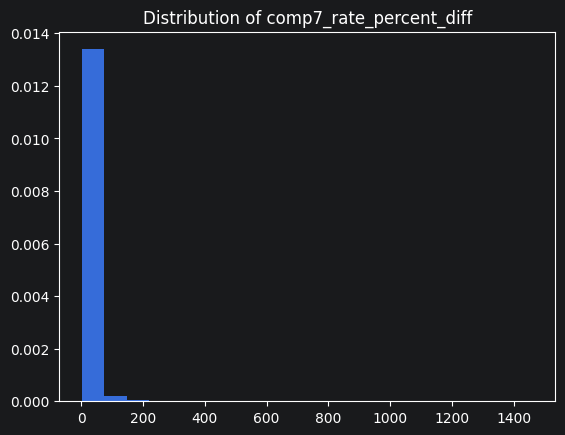

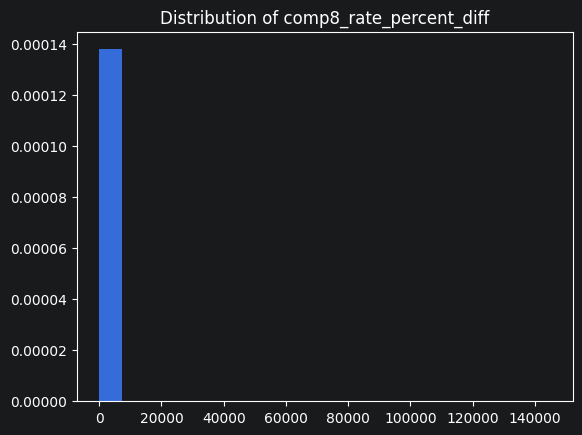

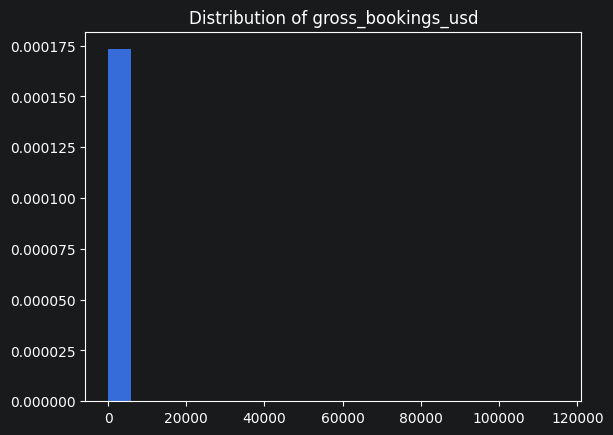

In [160]:
num_cols = df.select_dtypes(include=["number"]).columns

for col in num_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins = 20, density = True)
    plt.title(f"Distribution of {col}")
    plt.show()

### 2.5 Handling Outliers

In [161]:
df.describe()

,date_time,date,visitor_hist_starrating,visitor_hist_adr_usd,prop_review_score,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,...,orig_destination_distance,comp1_rate_percent_diff,comp2_rate_percent_diff,comp3_rate_percent_diff,comp4_rate_percent_diff,comp5_rate_percent_diff,comp6_rate_percent_diff,comp7_rate_percent_diff,comp8_rate_percent_diff,gross_bookings_usd
count,500000,500000,25751.000000,25899.000000,499300.000000,500000.000000,390302.000000,500000.000000,500000.000000,500000.000000,...,339129.000000,9265.000000,55659.000000,47948.000000,13341.000000,84347.000000,10098.000000,14730.000000,60738.000000,13905.000000
mean,2013-03-10 09:18:40.225861888,2013-03-09 19:08:20.198400,3.398338,177.382141,3.788203,2.882295,0.130305,4.342206,16.900250,208.652405,...,1290.160889,166.233673,21.763184,31.989489,57.615772,38.062656,16.710934,19.151867,20.478382,389.011139
min,2012-11-01 00:35:47,2012-11-01 00:00:00,1.670000,23.530001,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.010000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000
25%,2013-01-13 10:20:59,2013-01-13 00:00:00,2.980000,110.980003,3.500000,1.790000,0.019300,4.460000,8.000000,86.037500,...,137.020004,7.000000,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,7.000000,124.120003
50%,2013-03-13 11:02:46,2013-03-13 00:00:00,3.500000,155.850006,4.000000,2.770000,0.069100,4.920000,16.000000,124.000000,...,379.489990,10.000000,11.000000,11.000000,11.000000,12.000000,11.000000,11.000000,11.000000,219.789993
75%,2013-05-09 11:10:14,2013-05-09 00:00:00,3.940000,214.729996,4.500000,4.060000,0.179900,5.320000,26.000000,187.000000,...,1452.349976,16.000000,20.000000,18.000000,19.000000,21.000000,18.000000,20.000000,17.000000,431.320007
max,2013-06-30 23:20:46,2013-06-30 00:00:00,5.000000,928.760010,5.000000,6.980000,1.000000,6.210000,40.000000,822602.812500,...,11631.950195,11805.000000,168893.000000,143583.000000,159249.000000,159205.000000,1058.000000,1461.000000,144900.000000,115309.140625
std,NaN,NaN,0.679699,102.236328,1.038644,1.527376,0.159037,1.820183,10.433949,3902.071045,...,2010.717773,955.792908,721.201050,1228.214844,2401.271484,1533.466309,28.935125,42.958004,816.017212,1104.919434


#### Price USD

In [162]:
price_995 = df["price_usd"].quantile(q = 0.995)
price_995

np.float64(811.0013000488293)

In [163]:
df["price_usd"] = df["price_usd"].clip(upper = price_995)

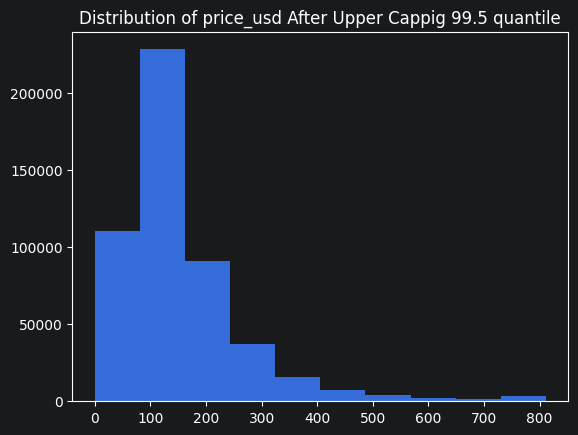

In [164]:
plt.figure()
plt.hist(df["price_usd"])
plt.title("Distribution of price_usd After Upper Cappig 99.5 quantile")
plt.show()

#### Gross Bookings

In [165]:
gross_usd_995 = df["gross_bookings_usd"].quantile(q = 0.995)
gross_usd_995

np.float32(3224.608)

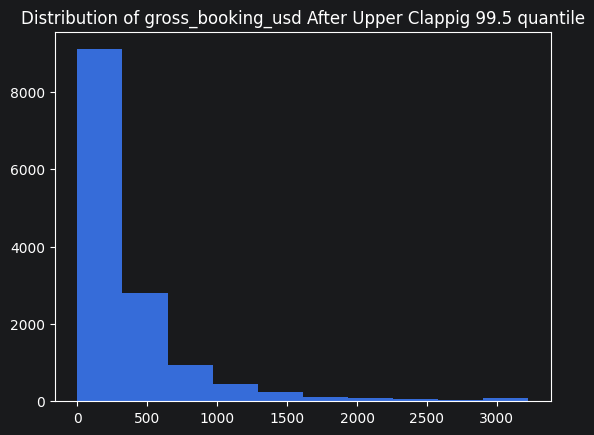

In [166]:
df["gross_bookings_usd"] = df["gross_bookings_usd"].clip(upper = gross_usd_995)
plt.figure()
plt.hist(df["gross_bookings_usd"])
plt.title("Distribution of gross_booking_usd After Upper Clappig 99.5 quantile")
plt.show()

#### Competition Rate Diff

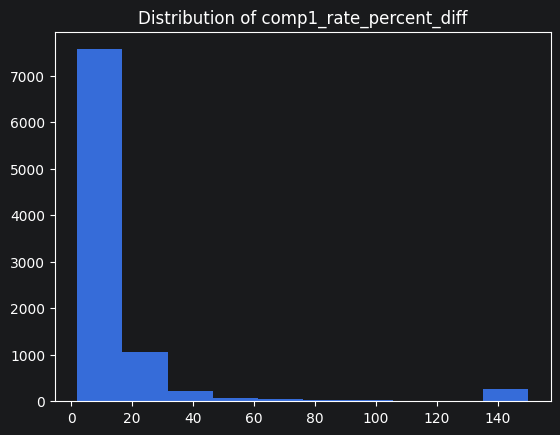

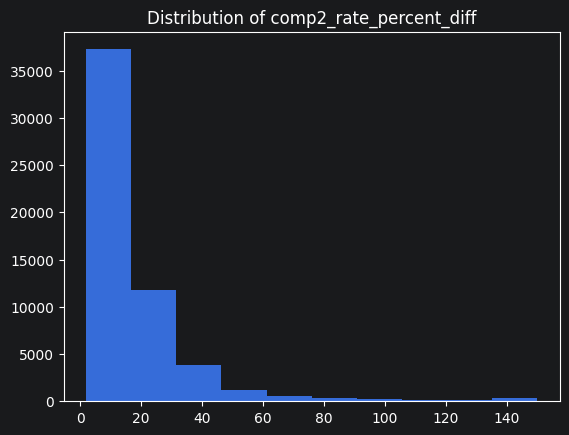

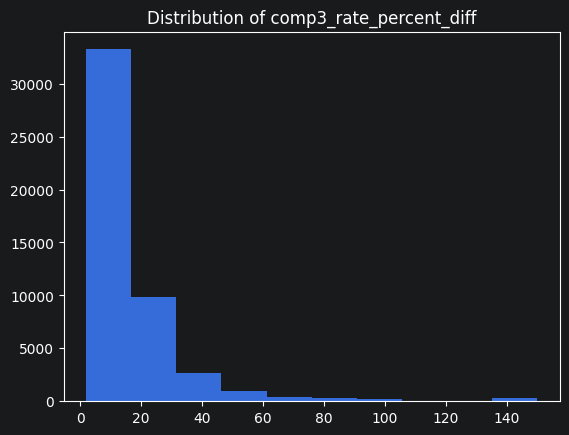

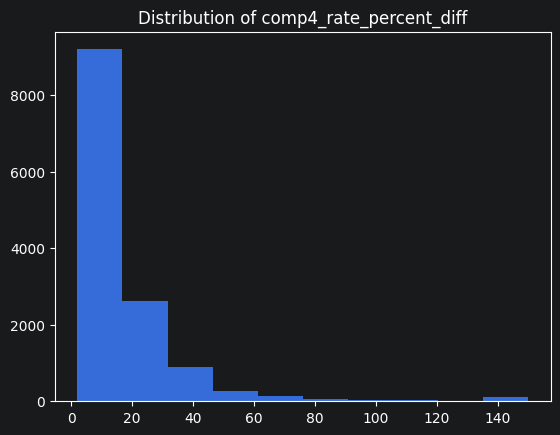

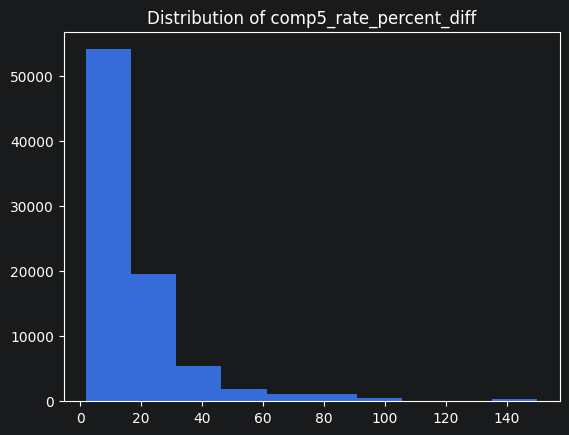

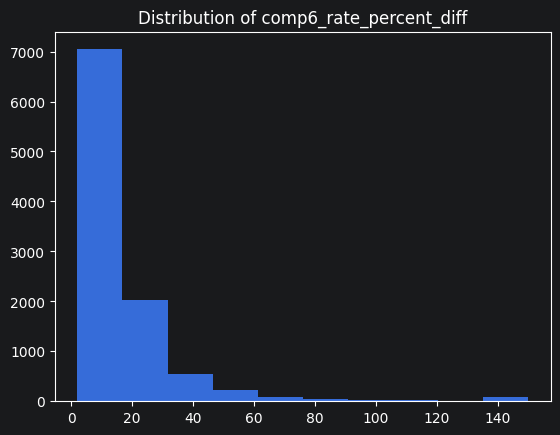

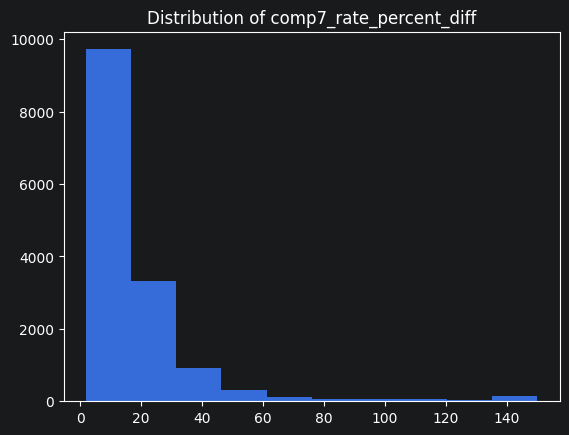

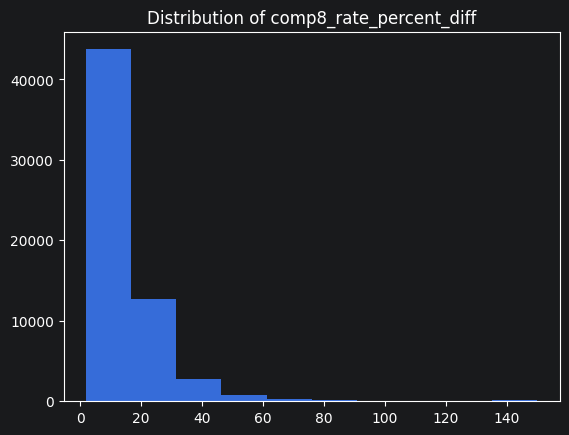

In [167]:
for i in range(1, 9):
    #upper995 = df[f"comp{i}_rate_percent_diff"].quantile(q = 0.995)
    df[f"comp{i}_rate_percent_diff"] = df[f"comp{i}_rate_percent_diff"].clip(upper = 150)
    plt.figure()
    plt.hist(df[f"comp{i}_rate_percent_diff"])
    plt.title(f"Distribution of comp{i}_rate_percent_diff")
    plt.show()


#### Search Booking Window

In [168]:
window_neg_ratio = df[df["srch_booking_window"] < 0].shape[0] / df.shape[0]
print(f"Ratio of faulty, negative values for booking window: {window_neg_ratio:.3f}")

Ratio of faulty, negative values for booking window: 0.063


In [169]:
# Create Negative Flag Feature for booking_window
df["booking_window_was_negative"] = (df["srch_booking_window"] < 0).astype("bool")

# Clip Values
df["srch_booking_window"] = df["srch_booking_window"].clip(lower = 0)

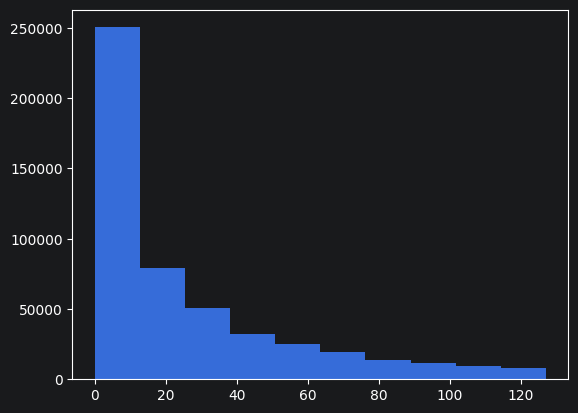

In [171]:
plt.figure()
plt.hist(df["srch_booking_window"])
plt.show()

### 2.6 Handling Time

In [172]:
# Creating Start of Stay Feature
df["start_of_stay"] = (df["date"] + pd.to_timedelta(df["srch_booking_window"], unit = "D"))

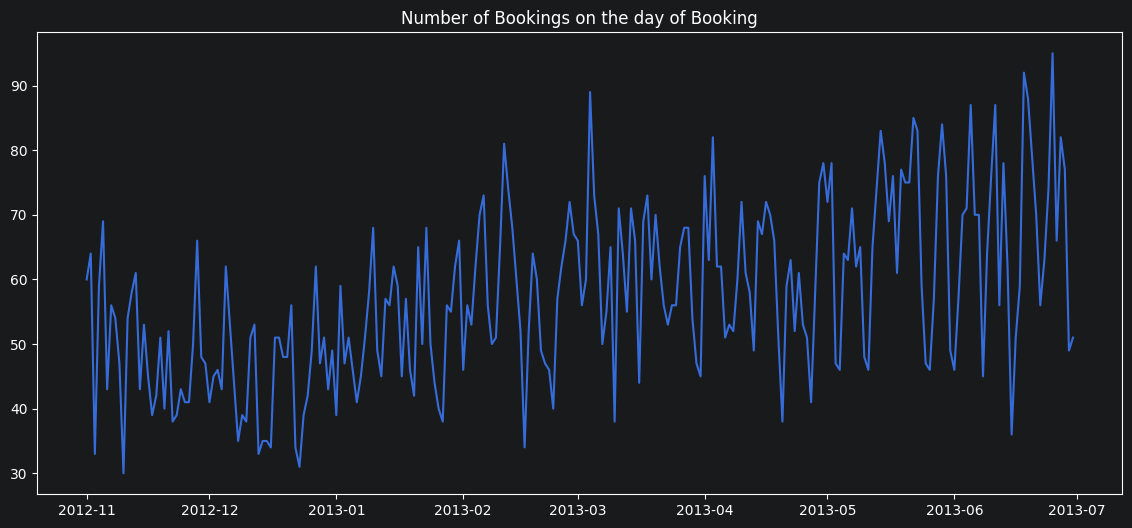

In [173]:
booking_days_sum = df.groupby("date")["booking_bool"].sum()
plt.figure(figsize = (14, 6))
plt.plot(booking_days_sum)
plt.title("Number of Bookings on the day of Booking")
plt.show()

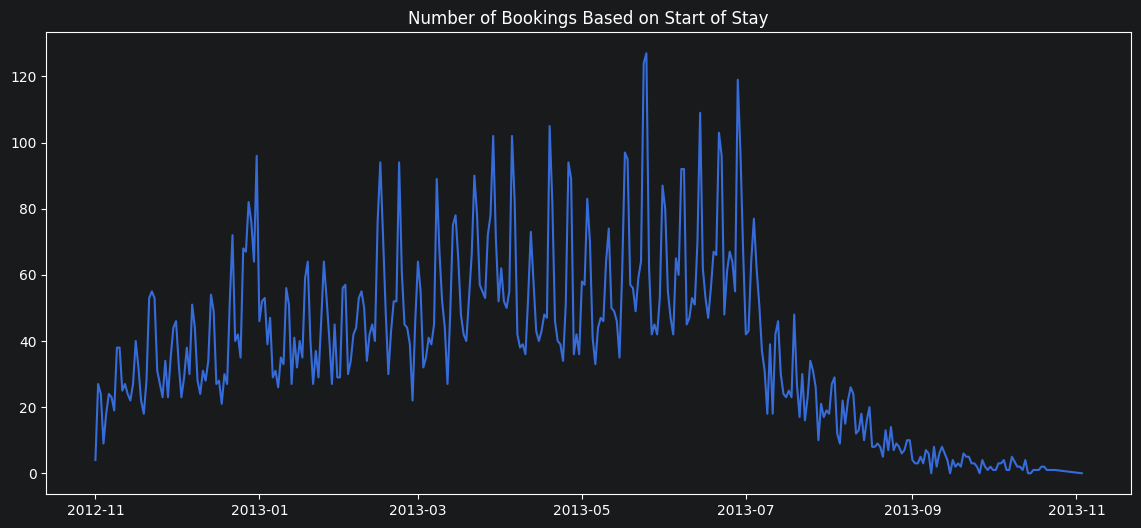

In [185]:
booking_start_sum = df.groupby("start_of_stay")["booking_bool"].sum()
plt.figure(figsize = (14, 6))
plt.plot(booking_start_sum)
plt.title("Number of Bookings Based on Start of Stay")
plt.show()

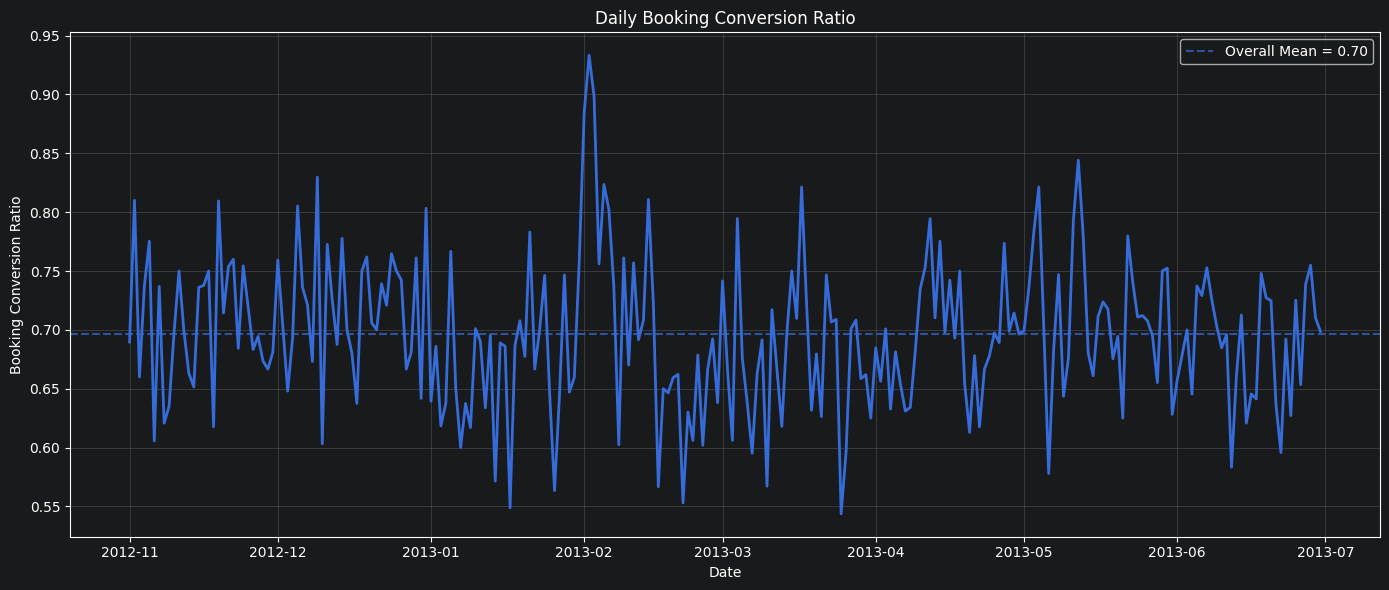

In [188]:
# ------------------------------------------
# Search-Level Daily Booking Conversion Rate
# ------------------------------------------

daily_booking_ratio = (
    df.groupby(["date", "srch_id"], observed=True)["booking_bool"]
      .max()                         # did this search end with a booking?
      .reset_index()
      .groupby("date")["booking_bool"]
      .mean()
)

# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    daily_booking_ratio.index,
    daily_booking_ratio.values,
    linewidth=2
)

# Overall booking conversion baseline
plt.axhline(
    y=daily_booking_ratio.mean(),
    linestyle="--",
    alpha=0.7,
    label=f"Overall Mean = {daily_booking_ratio.mean():.2f}"
)

plt.title("Daily Booking Conversion Ratio")
plt.xlabel("Date")
plt.ylabel("Booking Conversion Ratio")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [175]:
# Hourly Statistics
df["search_hour"] = df["date_time"].dt.hour
df["search_hour"] = df["search_hour"].astype("int8")
df["search_hour"].dtype

dtype('int8')

In [183]:
hourly_df = df.groupby("srch_id", observed=True).agg({
    "search_hour": "first",
    "booking_bool": "sum"
})


h_db = hourly_df.groupby("search_hour")["booking_bool"].mean()


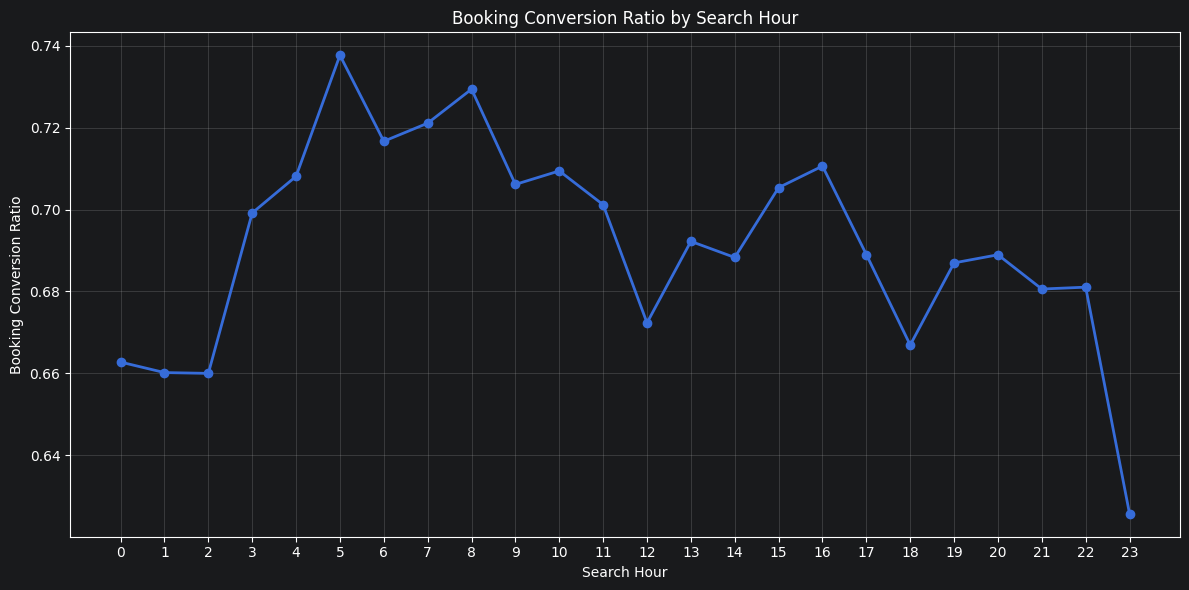

In [184]:
plt.figure(figsize=(12, 6))

plt.plot(
    h_db.index,
    h_db.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(24))
plt.xlabel("Search Hour")
plt.ylabel("Booking Conversion Ratio")
plt.title("Booking Conversion Ratio by Search Hour")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

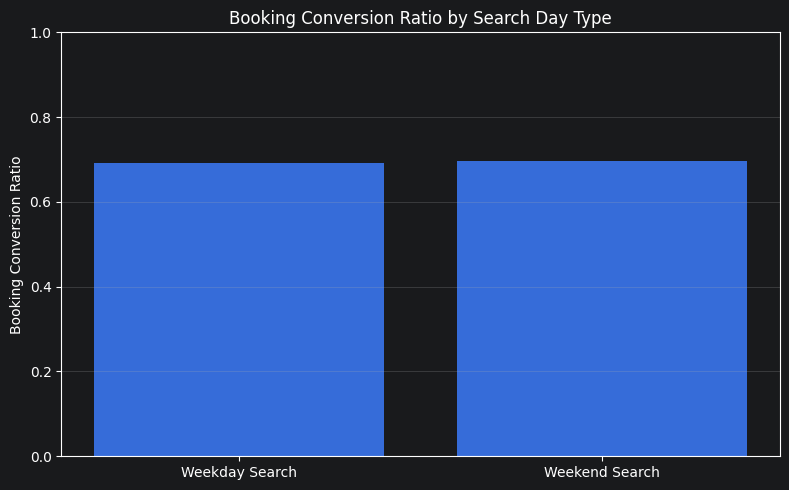

In [187]:
# Extract weekday
# Monday = 0, Sunday = 6
df["search_weekday"] = df["date_time"].dt.dayofweek

# Weekend search flag
df["is_weekend_search"] = (
    df["search_weekday"] >= 5
).astype("int8")


# ------------------------------------------
# Create Search-Level DataFrame
# ------------------------------------------

weekend_search_df = df.groupby("srch_id", observed=True).agg({
    "is_weekend_search": "mean",
    "booking_bool": "mean"
})

# Convert booking_bool into:
# Did this search end with a booking?
weekend_search_df["booking_bool"] = (
    weekend_search_df["booking_bool"] != 0
).astype("int8")


# ------------------------------------------
# Booking Conversion Ratio by Weekend Search
# ------------------------------------------

weekend_conversion = (
    weekend_search_df
    .groupby("is_weekend_search")["booking_bool"]
    .mean()
)


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    ["Weekday Search", "Weekend Search"],
    weekend_conversion.values
)

plt.ylabel("Booking Conversion Ratio")
plt.title("Booking Conversion Ratio by Search Day Type")

plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

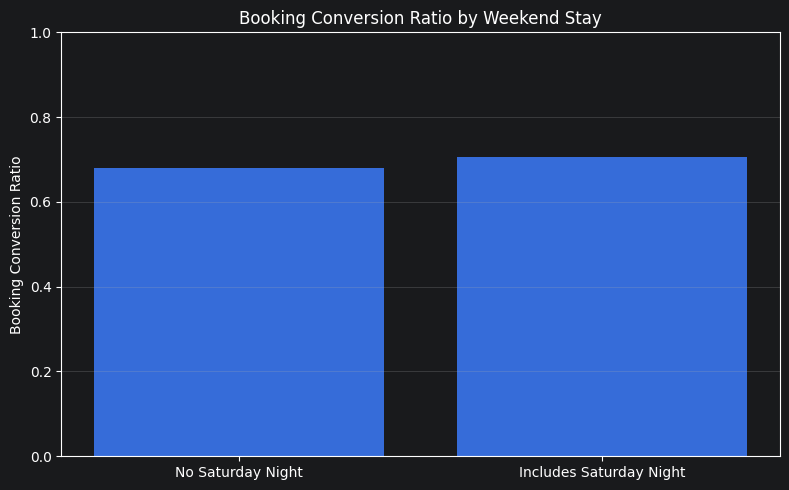

In [186]:
# Search-level dataframe
weekend_df = df.groupby("srch_id", observed=True).agg({
    "srch_saturday_night_bool": "mean",
    "booking_bool": "mean"
})

# Convert booking_bool into:
# did this search end with a booking?
weekend_df["booking_bool"] = (
    weekend_df["booking_bool"] != 0
).astype(int)

# Weekend vs non-weekend booking conversion ratio
weekend_ratio = (
    weekend_df
    .groupby("srch_saturday_night_bool")["booking_bool"]
    .mean()
)

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Saturday Night", "Includes Saturday Night"],
    weekend_ratio.values
)

plt.ylabel("Booking Conversion Ratio")
plt.title("Booking Conversion Ratio by Weekend Stay")

plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Group By Search ID Stats

In [177]:
# Booking Ratio
booking_ratio = (df.groupby("srch_id", observed = True)["booking_bool"].mean() != 0).mean()
print(f"Ratio of booking in a search: {booking_ratio:.2f}")

Ratio of booking in a search: 0.69


In [178]:
# At least one click Ratio per Search
click_ratio = (df.groupby("srch_id", observed = True)["click_bool"].sum() != 0).mean()
average_n_clicks = (df.groupby("srch_id", observed = True)["click_bool"].sum()).mean()
print(f"Ratio of clicking at least one time in a search: {click_ratio:.2f}")
print(f"Average number of clicks per search: {average_n_clicks:.2f}")

Ratio of clicking at least one time in a search: 1.00
Average number of clicks per search: 1.12
